# **Car Sales Data Analysis dan Price Prediction**
This notebook follows a structured approach to analyze car sales data and build a predictive model for car prices.

## **1. Memanggil Library yang diperlukan**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

## **2. Load data & Prerequisite**

In [7]:
url = '../../data/raw/Car_sales.xls'
df = pd.read_csv(url)
print("Data loaded successfully.")

Data loaded successfully.


## **3. Melihat Data**

In [8]:
display(df.head())
display(df.info())
display(df.describe())

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    str    
 15  Power_perf_factor    155 non-null    float64
dtypes

None

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


## **4. Menghapus dan Mengisi Missing Value**

In [9]:
# Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Filling numerical missing values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Dropping rows with remaining categorical missing values if any
df.dropna(inplace=True)

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64

Missing values after cleaning:
 Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64


## **6. Explorasi Data**

### 10 Jenis Mobil dengan Penjualan Terbanyak

C:\Users\ACER\AppData\Local\Temp\ipykernel_10584\635599188.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sales, x='Sales_in_thousands', y='Model', palette='viridis')


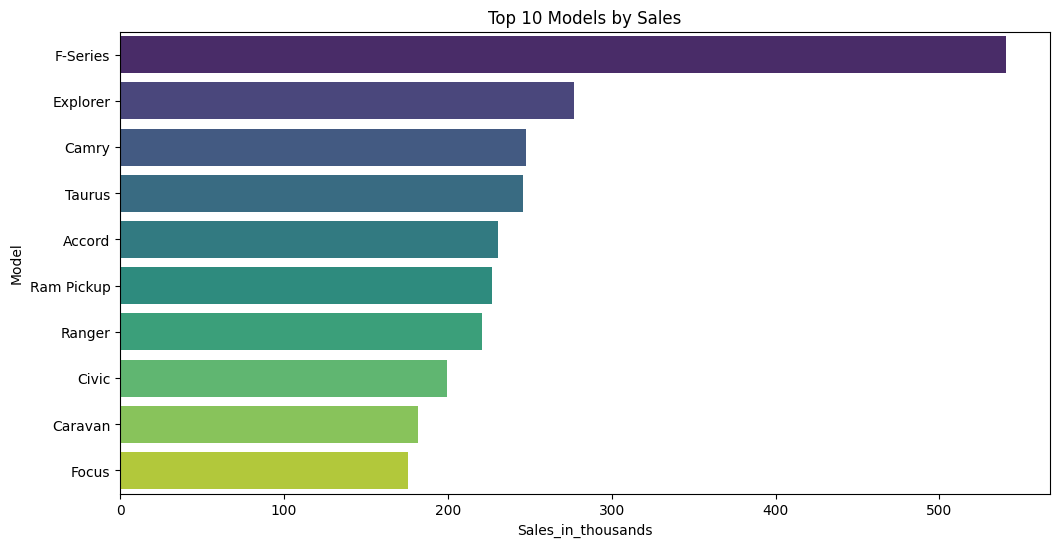

In [10]:
top_10_sales = df.nlargest(10, 'Sales_in_thousands')

plt.figure(figsize=(12,6))
sns.barplot(data=top_10_sales, x='Sales_in_thousands', y='Model', palette='viridis')
plt.title('Top 10 Models by Sales')
plt.show()

### Harga dan Spesifikasi Lain dari Top 10 Penjualan

In [11]:
# Displaying Price, Horsepower, Engine_size, and Fuel_capacity for the top 10
specs_top_10 = top_10_sales[['Manufacturer', 'Model', 'Sales_in_thousands', 'Price_in_thousands', 'Horsepower', 'Engine_size', 'Fuel_capacity']]
display(specs_top_10)

,Manufacturer,Model,Sales_in_thousands,Price_in_thousands,Horsepower,Engine_size,Fuel_capacity
56,Ford,F-Series,540.561,26.935,220.0,4.6,25.1
52,Ford,Explorer,276.747,31.930,210.0,4.0,21.0
137,Toyota,Camry,247.994,17.518,133.0,2.2,18.5
49,Ford,Taurus,245.815,17.885,155.0,3.0,16.0
58,Honda,Accord,230.902,15.350,135.0,2.3,17.1
40,Dodge,Ram Pickup,227.061,19.460,230.0,5.2,26.0
55,Ford,Ranger,220.650,12.050,119.0,2.5,20.0
57,Honda,Civic,199.685,12.885,106.0,1.6,11.9
45,Dodge,Caravan,181.749,19.565,150.0,2.4,20.0
50,Ford,Focus,175.670,12.315,107.0,2.0,13.2


## **7. Penentuan Variabel Rekomendasi**
Berdasarkan korelasi data, kita akan menggunakan variabel teknis seperti `Engine_size`, `Horsepower`, `Wheelbase`, dan `Fuel_capacity` untuk menentukan spesifikasi produksi.

## **8. Membuat Model Prediksi Harga Mobil**

### Memisahkan variable Independent (X) dan Dependent (y)

In [12]:
# We'll use numerical features to predict Price_in_thousands
features = ['Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']
X = df[features]
y = df['Price_in_thousands']




### Data Splitting
Dipisahkan menjadi 80% training set dan 20% test set

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Membuat Model Regresi

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluasi Model



In [15]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 9.489760917841442
R2 Score: 0.7379280743968633


### Scatter Plot Hasil Evaluasi



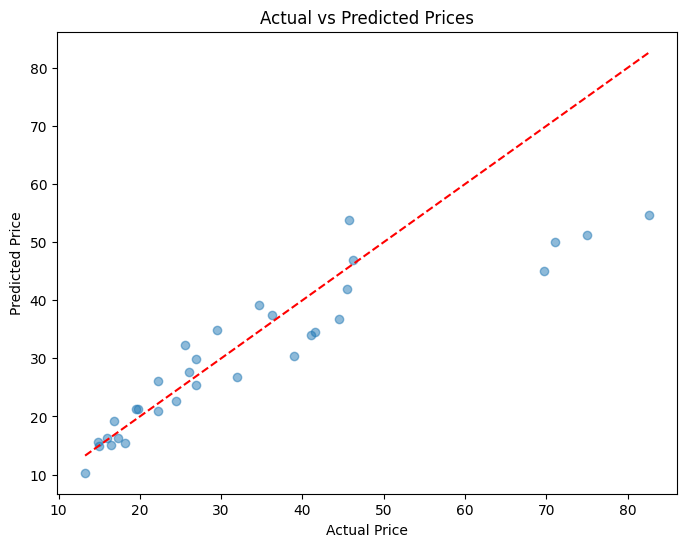

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

## **9. Memprediksi Harga dengan Spesifikasi Baru**

In [17]:
new_specs = pd.DataFrame({
    'Engine_size': [3.0],
    'Horsepower': [250],
    'Wheelbase': [105.0],
    'Width': [70.0],
    'Length': [180.0],
    'Curb_weight': [3.5],
    'Fuel_capacity': [18.0],
    'Fuel_efficiency': [22.0]
})

predicted_price = model.predict(new_specs)
print(f"Predicted Price for defined specs: ${predicted_price[0]:.2f} thousand")

Predicted Price for defined specs: $43.51 thousand
